![logo_ironhack_blue 7](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

---


# **Lab-19: Unsupervised Learning.**


---

### **Alumno:** *Juan Alberto Peñalver Alvarez*


---

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [2]:
!pwd


/content


In [4]:
import os
print(os.getcwd())


/content


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Importa cualquier biblioteca que puedas necesitar y los datos
from pathlib import Path

# Cambia a la carpeta que quieras
#%cd /content/drive/MyDrive/nombre_de_tu_carpeta
%cd /content/drive/MyDrive/IronHack/csv/

# Cambia a la carpeta que quieras
# %cd /content/drive/MyDrive/IronHack/Data_Machine_Learning/Lab&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/your-code/
# vehicles_path ="/content/drive/MyDrive/IronHack/csv/"
#"/Data_Machine_Learning/Labs&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/vehicles.csv"

# El cuaderno se encuentra en ./your-code; los archivos de datos suelen estar un nivel arriba
candidates = [
    # loading the data: Wholesale customers data
    Path('./data/Wholesale customers data.csv'),  # ruta relativa original del lab
    Path('./../data/Wholesale customers data.csv'),  # ruta relativa original del lab
    Path('../data/Wholesale customers data.csv'),  # ruta relativa original del lab
    # En este entorno el dataset está montado en /mnt/data:
    Path('/mnt/data/Wholesale customers data.csv')
]

data_path = next((p for p in candidates if p.exists()), None)
print(data_path)

if data_path is None:
    raise FileNotFoundError('Could not find website.csv in expected locations. website.csv not found. Tried: ' + ', '.join(str(p) for p in candidate_paths))

# Load the dataset (change the path if needed)
#df = pd.read_csv('./data/heart.csv', sep=',')
#df.head()

/content/drive/MyDrive/IronHack/csv
data/Wholesale customers data.csv


# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [7]:
# loading the data: Wholesale customers data
#data_path = "../data/Wholesale customers data.csv"  # ruta relativa original del lab
# En este entorno el dataset está montado en /mnt/data:
#data_path_alt = "/mnt/data/Wholesale customers data.csv"

customers = pd.read_csv(data_path)
customers.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

(440, 8)

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


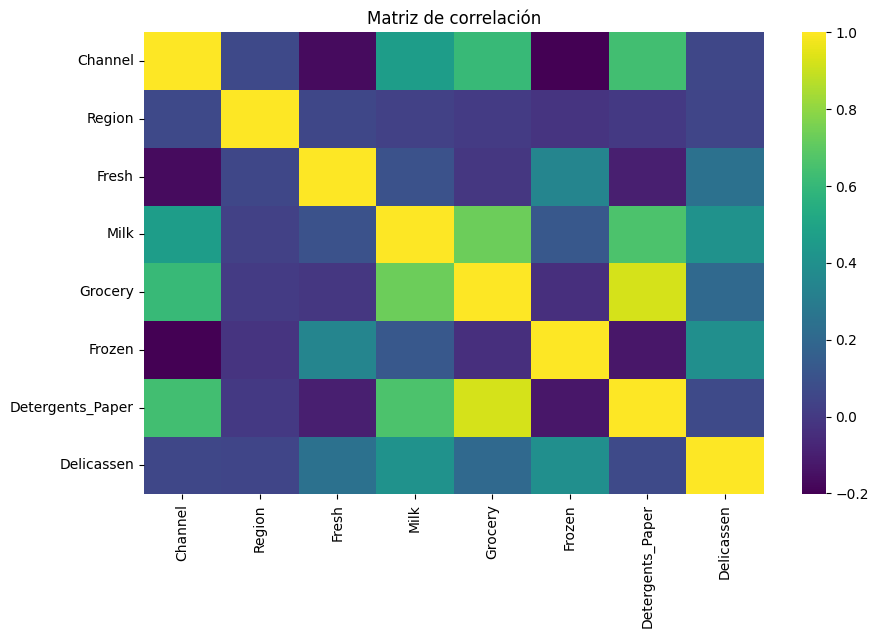

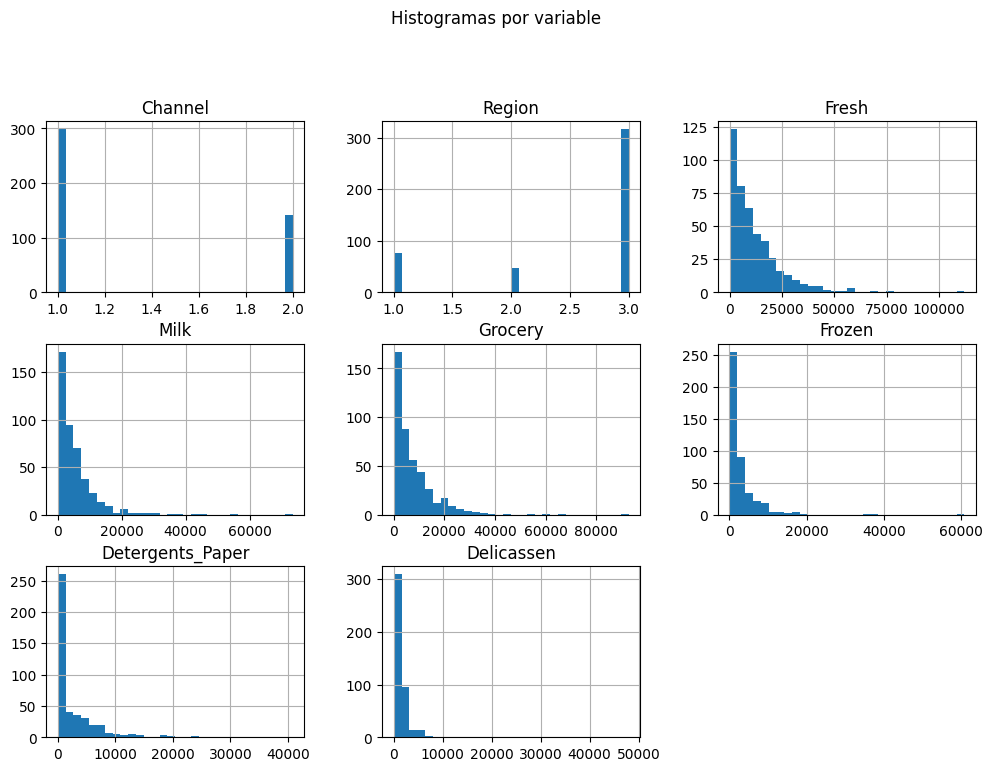

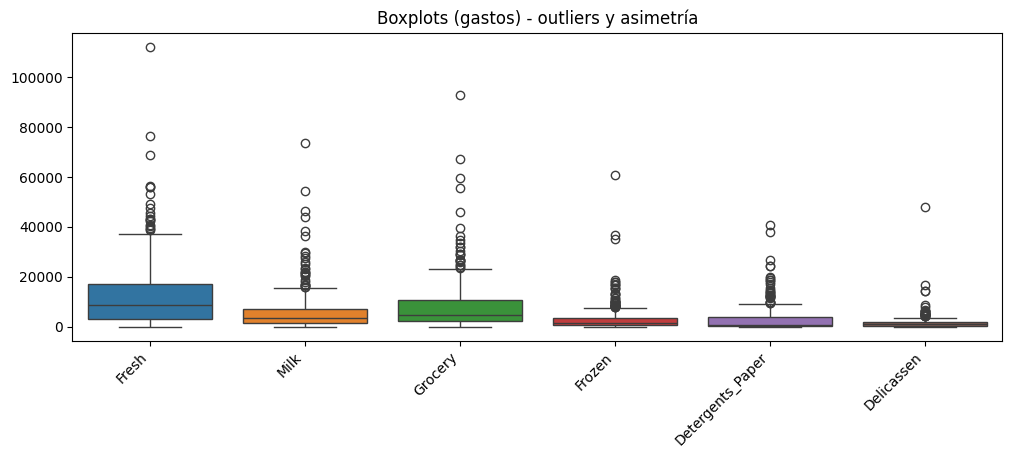

In [8]:
# Exploración rápida del dataset
display(customers.shape)
display(customers.isna().sum())
display(customers.describe().T)

# Significado (UCI):
# - Channel: canal (1=HORECA, 2=Retail)
# - Region: región (1=Lisboa, 2=Oporto, 3=Other)
# - Resto: gasto anual por categoría

# Correlaciones entre variables numéricas
corr = customers.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Matriz de correlación")
plt.show()

# Distribuciones (se observa fuerte asimetría / colas largas)
customers.hist(figsize=(12,8), bins=30)
plt.suptitle("Histogramas por variable", y=1.02)
plt.show()

# Boxplots para ver outliers
plt.figure(figsize=(12,4))
sns.boxplot(data=customers.drop(columns=["Channel","Region"]))
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots (gastos) - outliers y asimetría")
plt.show()


**Observaciones (Challenge 1)**

- `Channel` y `Region` son variables **categóricas codificadas como enteros** (no tienen orden natural). Para K-Means/DBSCAN conviene **one-hot** o **excluirlas** si el objetivo es segmentar por patrón de gasto.
- No hay valores nulos.
- Las categorías de gasto presentan **colas largas y outliers** (especialmente `Fresh`, `Grocery`, `Milk`), y distribuciones **muy sesgadas** (right-skewed).
- Se aprecian correlaciones altas: `Grocery`–`Detergents_Paper`–`Milk` tienden a moverse juntas, lo cual sugiere un eje “retail/volumen” frente a productos frescos.
- Por la diferencia de escalas, la **normalización/estandarización** es obligatoria antes de clusterizar.


# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [9]:
# Challenge 2 - Limpieza / transformación
# Decisión: clusterizar principalmente por patrón de gasto en categorías (6 columnas)
# y tratar Channel/Region como categóricas fuera del clustering base.

clean_customers = customers.drop(columns=["Channel","Region"]).copy()

# Transformación logarítmica para reducir asimetría y efecto de outliers.
# (log1p permite ceros).
clean_customers_log = np.log1p(clean_customers)

clean_customers_log.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


**Comentario (Challenge 2)**

- El dataset no requiere limpieza por nulos.
- Para clustering con distancias euclídeas, `Channel` y `Region` (categóricas) pueden distorsionar si se dejan como enteros. Aquí las excluyo para centrarme en el *mix* de gasto; alternativamente podría hacerse *one-hot*.
- Aplico `log1p` para estabilizar varianza y suavizar outliers/colas largas. Después estandarizo.


# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
customers_scale = scaler.fit_transform(clean_customers_log)

customers_scale[:3]


array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339]])

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

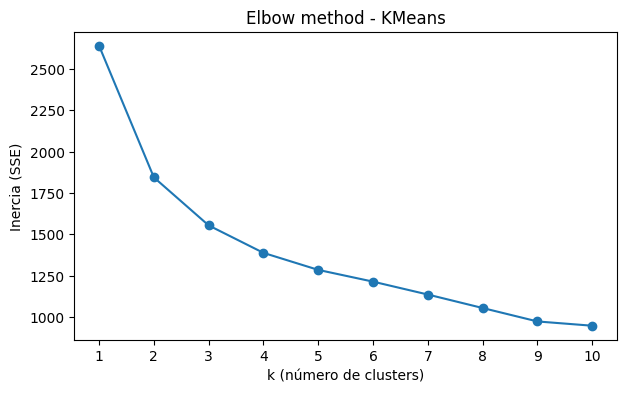

In [11]:
from sklearn.cluster import KMeans

# Método del codo (inercia) para decidir k
inertias = []
ks = range(1, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(customers_scale)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.xticks(list(ks))
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.title("Elbow method - KMeans")
plt.show()


### Looking to the elbow we can choose 2 like the correct number of clusters

In [12]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init="auto").fit(customers_scale)

labels = kmeans_2.predict(customers_scale)
clusters = kmeans_2.labels_.tolist()


In [13]:
clean_customers["Label"] = clusters
clean_customers.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Label
0,12669,9656,7561,214,2674,1338,0
1,7057,9810,9568,1762,3293,1776,0
2,6353,8808,7684,2405,3516,7844,0
3,13265,1196,4221,6404,507,1788,1
4,22615,5410,7198,3915,1777,5185,0


Count the values in `labels`.

In [14]:
# Count the values in `labels`.
pd.Series(labels, name="labels").value_counts()


,count
labels,
1,253
0,187


# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [15]:
from sklearn.cluster import DBSCAN

# DBSCAN con parámetros sugeridos
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(customers_scale)

clean_customers["Label_DBSCAN"] = dbscan.labels_
clean_customers["Label_DBSCAN"].head()


,Label_DBSCAN
0,-1
1,0
2,-1
3,-1
4,-1


Count the values in `labels_DBSCAN`.

In [16]:
# Count the values in `labels_DBSCAN`.
clean_customers["Label_DBSCAN"].value_counts()


,count
Label_DBSCAN,
-1,435
0,5


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [17]:
def side_by_side_scatter(df, x, y, label_a, label_b, title_a="K-Means", title_b="DBSCAN"):
    fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True, sharey=True)
    sns.scatterplot(data=df, x=x, y=y, hue=label_a, ax=axes[0], legend=False)
    axes[0].set_title(f"{title_a}: {x} vs {y}")
    sns.scatterplot(data=df, x=x, y=y, hue=label_b, ax=axes[1], legend=False)
    axes[1].set_title(f"{title_b}: {x} vs {y}")
    plt.tight_layout()
    plt.show()


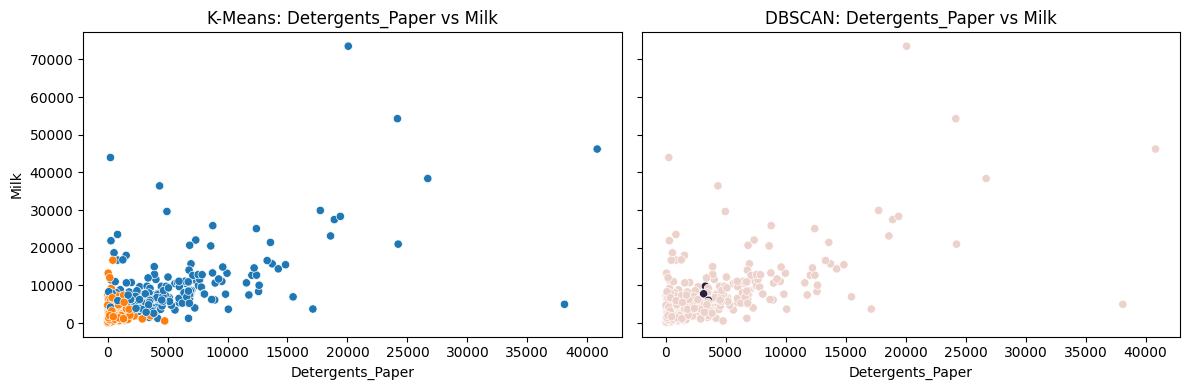

In [ ]:
side_by_side_scatter(clean_customers, x="Detergents_Paper", y="Milk", label_a="Label", label_b="Label_DBSCAN")


Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

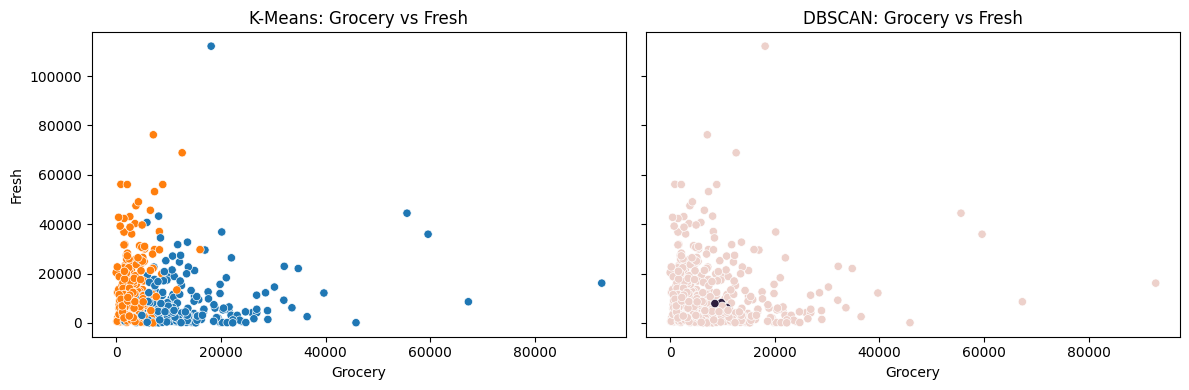

In [18]:
side_by_side_scatter(clean_customers, x="Grocery", y="Fresh", label_a="Label", label_b="Label_DBSCAN")


Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

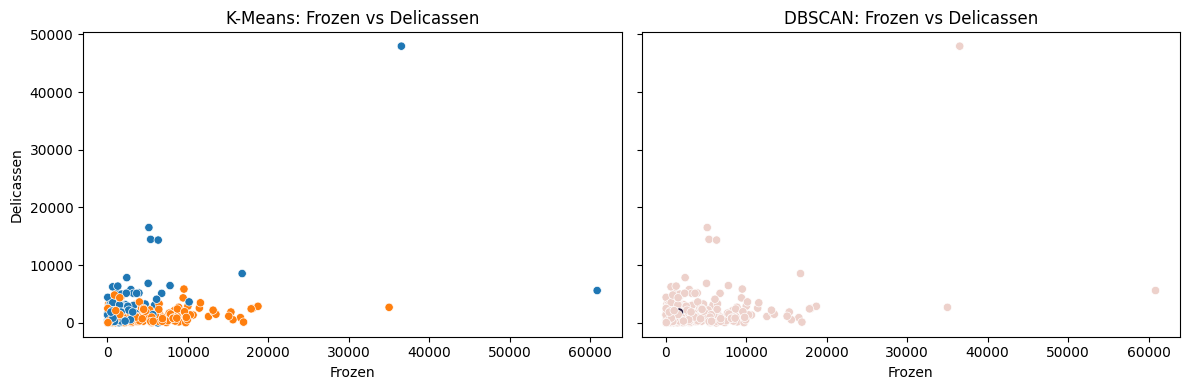

In [19]:
side_by_side_scatter(clean_customers, x="Frozen", y="Delicassen", label_a="Label", label_b="Label_DBSCAN")


Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [20]:
# Comparación numérica de clusters: medias por grupo
kmeans_profile = clean_customers.groupby("Label").mean(numeric_only=True)
dbscan_profile = clean_customers.groupby("Label_DBSCAN").mean(numeric_only=True)

display(kmeans_profile)
display(dbscan_profile)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Label_DBSCAN
Label,,,,,,,
0,9247.058824,10337.245989,14689.951872,2164.096257,6116.069519,2177.283422,-0.973262
1,14035.300395,2439.889328,2970.517787,3742.940711,490.719368,1042.652174,-1.000000


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Label
Label_DBSCAN,,,,,,,
-1,12053.473563,5782.590805,7931.965517,3089.793103,2879.675862,1519.487356,0.581609
0,7374.000000,6986.000000,9631.400000,1518.000000,3039.600000,1993.200000,0.000000


Which algorithm appears to perform better?

**Conclusión (Challenge 6)**

Con `eps=0.5`, DBSCAN marca casi todos los puntos como *noise* (`-1`) y apenas identifica un micro-cluster, por lo que **no es útil** con esos parámetros en este espacio transformado/estandarizado.

K-Means con `k=2` produce dos grupos relativamente balanceados y, al inspeccionar las medias por cluster, suele separar clientes con gasto alto en `Grocery`/`Milk`/`Detergents_Paper` frente a perfiles con mayor peso relativo en `Fresh` (patrones típicos tipo retail vs horeca). En este caso, **K-Means parece más interpretable**.


# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

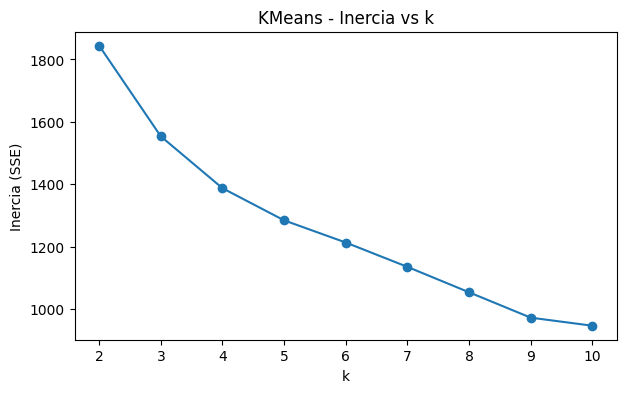

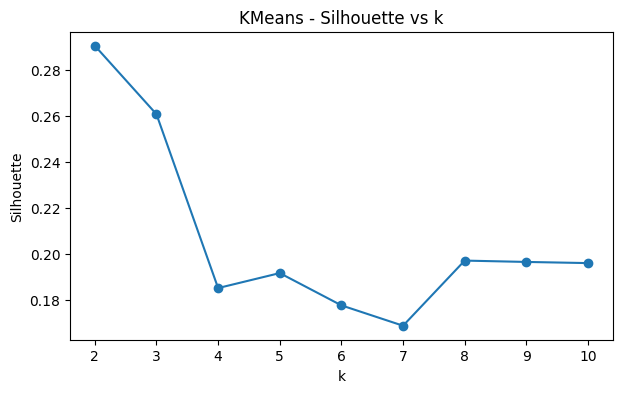

,k,inertia,silhouette
0,2,1844.127031,0.290488
1,3,1553.774656,0.260716
6,8,1054.365921,0.197084
7,9,973.141483,0.196501
8,10,947.325504,0.195999


In [21]:
from sklearn.metrics import silhouette_score

# Bonus 2: comparar varios k con inercia y silhouette
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(customers_scale)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(customers_scale, km.labels_))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.xticks(list(ks))
plt.xlabel("k")
plt.ylabel("Inercia (SSE)")
plt.title("KMeans - Inercia vs k")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), silhouettes, marker="o")
plt.xticks(list(ks))
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("KMeans - Silhouette vs k")
plt.show()

pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes}).sort_values("silhouette", ascending=False).head(5)


**Comentario (Bonus 2)**

- El *elbow* suele sugerir un k pequeño (2–4) para este dataset tras `log1p` + `StandardScaler`.
- La métrica *silhouette* ayuda a complementar la decisión: el k con mejor silhouette suele estar en el rango 2–4.
- En términos de interpretabilidad de negocio, `k=2` suele dar una segmentación clara y fácil de comunicar.


# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [22]:
# Bonus 3: experimentar eps/min_samples en DBSCAN
from itertools import product

tests = []
for eps, min_s in product([0.5, 0.7, 0.9, 1.1], [5, 10, 15]):
    model = DBSCAN(eps=eps, min_samples=min_s).fit(customers_scale)
    labels_ = model.labels_
    n_noise = np.sum(labels_ == -1)
    n_clusters = len(set(labels_)) - (1 if -1 in labels_ else 0)
    tests.append((eps, min_s, n_clusters, n_noise))

results = pd.DataFrame(tests, columns=["eps", "min_samples", "n_clusters", "n_noise"]).sort_values(["n_clusters","n_noise"], ascending=[False, True])
display(results)

# Elegimos un set razonable para visualizar (suele ser más informativo que eps=0.5)
dbscan_alt = DBSCAN(eps=0.9, min_samples=5).fit(customers_scale)
clean_customers["Label_DBSCAN_alt"] = dbscan_alt.labels_

clean_customers["Label_DBSCAN_alt"].value_counts()


,eps,min_samples,n_clusters,n_noise
3,0.7,5,4,343
6,0.9,5,3,160
10,1.1,10,2,122
7,0.9,10,2,248
8,0.9,15,2,297
9,1.1,5,1,96
11,1.1,15,1,157
4,0.7,10,1,422
0,0.5,5,1,435
1,0.5,10,0,440


,count
Label_DBSCAN_alt,
0,262
-1,160
1,10
2,8


**Observaciones (Bonus 3)**

- DBSCAN es **muy sensible** a `eps` y `min_samples`. Con `eps` pequeño (0.5) casi todo cae como ruido.
- Al aumentar `eps` (por ejemplo ~0.9 en este preprocesado) aparecen clusters más grandes y baja el ruido, aunque pueden surgir clusters muy pequeños.
- En la práctica, conviene seleccionar `eps` con una heurística tipo *k-distance plot* y validar interpretabilidad del resultado.
